# EEG_09 — HGNN Subject-Independent Ablation

Hypergraph Neural Network (Feng et al. 2019, AAAI) su dataset ipergrafi da EEG_07f.
Ablation: 5 metriche × **pruned only** = 5 configurazioni.
Split: TRAIN sogg 0-49, VAL 50-59, TEST 60-73.

**Paradigma**: GRAPH CLASSIFICATION — 1 ipergrafo per trial.
**Grafi**: consensus-pruned (majority vote ≥2/4 metriche) — raw esclusi.
**Instance norm**: attiva (z-score per-canale per-trial, Bomatter 2024).

In [ ]:
import json, logging, re, time
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import balanced_accuracy_score
from tqdm.auto import tqdm
import wandb

logging.basicConfig(level=logging.INFO, format='%(asctime)s %(levelname)-8s %(message)s', datefmt='%H:%M:%S')
log = logging.getLogger('eeg09')

project_root = next((p for p in [Path.cwd()]+list(Path.cwd().parents) if (p/'.git').exists()), Path.cwd())
FIG_DIR = project_root / 'figures'; FIG_DIR.mkdir(exist_ok=True)

# ---- CONFIG ----
SFREQ        = 256
N_CHANNELS   = 61
N_SAMPLES    = 384
N_CLASSES    = 4
CLUSTER_SCHEME = 'concr4'

EXCLUDE_SUBJ = {22, 23, 73}  # P022/P023 outlier 50 Hz, P073 un solo trial
SUBJ_TRAIN = [s for s in range(0, 60)  if s not in EXCLUDE_SUBJ]   # 58 soggetti
SUBJ_VAL   = [s for s in range(60, 70) if s not in EXCLUDE_SUBJ]   # 10
SUBJ_TEST  = [s for s in range(70, 91) if s not in EXCLUDE_SUBJ]   # 20

LR           = 1e-3
WEIGHT_DECAY = 5e-3    # alzato da 1e-4
GRAD_CLIP    = 1.0
BATCH_SIZE   = 64
MAX_EPOCHS   = 60
PATIENCE     = 7
HIDDEN       = 64
N_LAYERS     = 1
DROPOUT      = 0.6     # alzato da 0.3
LABEL_SMOOTHING   = 0.1
USE_INSTANCE_NORM = True

# Data augmentation — solo su training set
USE_AUGMENTATION = True
AUG_NOISE_STD    = 0.05
AUG_AMP_RANGE    = (0.85, 1.15)
AUG_SHIFT_MAX    = 15
AUG_MASK_LEN     = 20

METRICS = ['pcc', 'abs_pcc', 'im_pcc', 'wpli', 'plv']
VARIANTS = [True]   # pruned only

WANDB_ENTITY  = 'uras-daniele22-politecnico-di-milano'
WANDB_PROJECT = 'miralis-imagined-speech'

_PAT = re.compile(r'^P(\d+)_S(\d+)$')
label2cluster = {int(k): int(v) for k,v in json.loads(
    (project_root/'configs'/'label_schemes'/'labelid2cluster_concr4.json').read_text()).items()}

log.info(f'SUBJ_TRAIN={len(SUBJ_TRAIN)} VAL={len(SUBJ_VAL)} TEST={len(SUBJ_TEST)}')
log.info(f'DROPOUT={DROPOUT}  WEIGHT_DECAY={WEIGHT_DECAY}  GRAD_CLIP={GRAD_CLIP}  USE_AUG={USE_AUGMENTATION}')

## §2 — Dataset

In [ ]:
def _augment_eeg(x: torch.Tensor) -> torch.Tensor:
    x = x.clone()
    if torch.rand(1) < 0.5:
        x = x + torch.randn_like(x) * AUG_NOISE_STD
    if torch.rand(1) < 0.5:
        x = x * torch.empty(1).uniform_(*AUG_AMP_RANGE)
    if torch.rand(1) < 0.5:
        shift = torch.randint(-AUG_SHIFT_MAX, AUG_SHIFT_MAX + 1, (1,)).item()
        x = torch.roll(x, shift, dims=1)
    if torch.rand(1) < 0.3:
        T = x.shape[1]
        start = torch.randint(0, max(1, T - AUG_MASK_LEN), (1,)).item()
        x[:, start:start + AUG_MASK_LEN] = 0.0
    if torch.rand(1) < 0.2:
        ch = torch.randint(0, x.shape[0], (1,)).item()
        x[ch] = 0.0
    return x


class HypergraphDataset(Dataset):
    """Carica PT ipergrafi da EEG_07f. Keys: H (61,E), x (61,384), y."""
    def __init__(self, subj_ids, metric, pruned, use_instance_norm=True, augment=False):
        kind = 'hypergraphs_pruned' if pruned else 'hypergraphs'
        root = project_root / 'data' / f'{kind}_{metric}'
        self.paths, self.labels = [], []
        self.use_instance_norm = use_instance_norm
        self.augment = augment
        for p in sorted(root.rglob('trial_*.pt')):
            m = _PAT.match(p.parent.name)
            if not m: continue
            sid = int(m.group(1))
            if sid not in subj_ids: continue
            d = torch.load(p, weights_only=False)
            y_word = int(d['y'].squeeze()) if isinstance(d['y'], torch.Tensor) else int(d['y'])
            c = label2cluster.get(y_word)
            if c is None: continue
            self.paths.append(p)
            self.labels.append(c)
        log.info(f'  {kind}_{metric}: {len(self.paths)} trial, {len(set(self.labels))} classi')

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx):
        d = torch.load(self.paths[idx], weights_only=False)
        x = d['x'].float()   # (61, 384)
        H = d['H'].float()   # (61, E)
        if self.use_instance_norm:
            x = (x - x.mean(dim=1, keepdim=True)) / (x.std(dim=1, keepdim=True) + 1e-6)
        if self.augment:
            x = _augment_eeg(x)
        if H.shape[1] < N_CHANNELS:
            H = F.pad(H, (0, N_CHANNELS - H.shape[1]))
        elif H.shape[1] > N_CHANNELS:
            H = H[:, :N_CHANNELS]
        return x, H, torch.tensor(self.labels[idx], dtype=torch.long)


def make_loaders(metric, pruned):
    tr = HypergraphDataset(SUBJ_TRAIN, metric, pruned, USE_INSTANCE_NORM, augment=USE_AUGMENTATION)
    va = HypergraphDataset(SUBJ_VAL,   metric, pruned, USE_INSTANCE_NORM, augment=False)
    te = HypergraphDataset(SUBJ_TEST,  metric, pruned, USE_INSTANCE_NORM, augment=False)
    kw = dict(num_workers=2, pin_memory=True)
    labels   = np.array(tr.labels)
    counts   = np.bincount(labels, minlength=N_CLASSES)
    sample_w = torch.tensor(1.0 / counts[labels], dtype=torch.float)
    sampler  = WeightedRandomSampler(sample_w, len(sample_w), replacement=True)
    return (DataLoader(tr, BATCH_SIZE, sampler=sampler, **kw),
            DataLoader(va, BATCH_SIZE, shuffle=False, **kw),
            DataLoader(te, BATCH_SIZE, shuffle=False, **kw))

## §3 — HGNN Model (Feng et al. 2019)

In [3]:
class HGNNConv(nn.Module):
    """HGNN layer: X' = Dv^{-1/2} H W De^{-1} H^T Dv^{-1/2} X Theta"""
    def __init__(self, in_ch, out_ch, bias=True):
        super().__init__()
        self.weight = nn.Parameter(torch.empty(in_ch, out_ch))
        self.bias   = nn.Parameter(torch.zeros(out_ch)) if bias else None
        nn.init.xavier_uniform_(self.weight)

    def forward(self, X, H):
        # X: (B, N, C_in)  H: (B, N, E)
        d_v = H.sum(dim=2).clamp(min=1e-6)           # (B, N)
        d_e = H.sum(dim=1).clamp(min=1e-6)           # (B, E)
        Dv_inv_sqrt = (1.0 / d_v.sqrt()).unsqueeze(-1)  # (B, N, 1)
        De_inv      = (1.0 / d_e).unsqueeze(1)          # (B, 1, E)

        XW  = X @ self.weight                            # (B, N, C_out)
        out = Dv_inv_sqrt * XW                           # (B, N, C_out)
        out = torch.bmm(H.transpose(1,2), out)           # (B, E, C_out)
        out = De_inv.transpose(1,2) * out                # (B, E, C_out)
        out = torch.bmm(H, out)                          # (B, N, C_out)
        out = Dv_inv_sqrt * out                          # (B, N, C_out)
        if self.bias is not None:
            out = out + self.bias
        return out


class HGNN(nn.Module):
    def __init__(self, in_ch=N_SAMPLES, hidden=HIDDEN, n_classes=N_CLASSES,
                 n_layers=N_LAYERS, dropout=DROPOUT):
        super().__init__()
        dims = [in_ch] + [hidden] * n_layers
        self.convs = nn.ModuleList([HGNNConv(dims[i], dims[i+1]) for i in range(n_layers)])
        self.bn    = nn.ModuleList([nn.BatchNorm1d(hidden) for _ in range(n_layers)])
        self.drop  = nn.Dropout(dropout)
        self.clf   = nn.Linear(hidden, n_classes)

    def forward(self, x, H):
        # x: (B, N, T)  H: (B, N, E)
        out = x
        for conv, bn in zip(self.convs, self.bn):
            out = conv(out, H)            # (B, N, hidden)
            B, N, C = out.shape
            out = bn(out.reshape(B*N, C)).reshape(B, N, C)
            out = F.relu(out)
            out = self.drop(out)
        out = out.mean(dim=1)             # (B, hidden) — global mean pool
        return self.clf(out)              # (B, n_classes)

# quick sanity check
_m = HGNN(); _x = torch.randn(4, N_CHANNELS, N_SAMPLES); _H = torch.rand(4, N_CHANNELS, N_CHANNELS)
assert _m(_x, _H).shape == (4, N_CLASSES), 'forward check FAIL'
log.info('HGNN model OK')
del _m, _x, _H


11:56:52 INFO     HGNN model OK


## §4 — Train / Eval

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
log.info(f'device: {device}')

_criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING)


def run_epoch(model, loader, optimizer=None):
    train = optimizer is not None
    model.train() if train else model.eval()
    total_loss, all_labels, all_preds = 0.0, [], []
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for x, H, y in loader:
            x, H, y = x.to(device), H.to(device), y.to(device)
            logits = model(x, H)
            loss = _criterion(logits, y)
            if train:
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()
            total_loss += loss.item() * len(y)
            all_labels.extend(y.cpu().numpy())
            all_preds.extend(logits.argmax(1).cpu().numpy())
    bacc = balanced_accuracy_score(all_labels, all_preds)
    return total_loss / len(loader.dataset), bacc, np.array(all_labels), np.array(all_preds)


def train_model(run_name, tr_loader, va_loader, te_loader, config):
    run = wandb.init(entity=WANDB_ENTITY, project=WANDB_PROJECT,
                     name=run_name, config=config, reinit='finish_previous',
                     settings=wandb.Settings(start_method='thread'))
    model = HGNN().to(device)
    opt   = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=MAX_EPOCHS)
    best_val, best_state, patience_cnt = 0.0, None, 0

    for epoch in range(1, MAX_EPOCHS + 1):
        tr_loss, tr_bacc, _, _ = run_epoch(model, tr_loader, opt)
        va_loss, va_bacc, _, _ = run_epoch(model, va_loader)
        sched.step()
        run.log({'train/loss': tr_loss, 'train/bacc': tr_bacc,
                 'val/loss': va_loss,   'val/bacc': va_bacc,
                 'train_val_gap': tr_bacc - va_bacc,
                 'epoch': epoch})
        if va_bacc > best_val:
            best_val = va_bacc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_cnt = 0
        else:
            patience_cnt += 1
        if patience_cnt >= PATIENCE:
            log.info(f'  early stop epoch {epoch}'); break

    model.load_state_dict(best_state)
    _, te_bacc, te_labels, te_preds = run_epoch(model, te_loader)
    run.summary['val_bacc']  = best_val
    run.summary['test_bacc'] = te_bacc
    run.log({'confusion_matrix': wandb.plot.confusion_matrix(
        preds=te_preds.tolist(), y_true=te_labels.tolist(),
        class_names=['CONCR', 'AZIONE', 'STATO', 'ASTRATTO'])})
    run.finish()
    log.info(f'  {run_name}: val={best_val:.4f} test={te_bacc:.4f}')
    return best_val, te_bacc, te_labels, te_preds

## §5 — Ablation Loop (5 config — pruned only)

In [5]:
RESULTS = {}  # (metric, pruned) -> {val, test}

for metric in METRICS:
    for pruned in VARIANTS:
        key  = f'{metric}_{"pruned" if pruned else "raw"}'
        name = f'eeg09_HGNN_{key}_{CLUSTER_SCHEME}'
        log.info(f'\n=== {name} ===')

        try:
            tr_l, va_l, te_l = make_loaders(metric, pruned)
        except Exception as e:
            log.warning(f'  Skip {key}: {e}'); continue

        cfg = dict(notebook='EEG_09', model='HGNN', metric=metric, pruned=pruned,
                   n_classes=N_CLASSES, cluster_scheme=CLUSTER_SCHEME,
                   hidden=HIDDEN, n_layers=N_LAYERS, dropout=DROPOUT,
                   lr=LR, batch_size=BATCH_SIZE, max_epochs=MAX_EPOCHS,
                   use_instance_norm=USE_INSTANCE_NORM,
                   n_train_subj=len(SUBJ_TRAIN))

        val_b, test_b, lbl, pred = train_model(name, tr_l, va_l, te_l, cfg)
        RESULTS[key] = {'val': val_b, 'test': test_b}

log.info('\n=== ABLATION DONE ===')
for k, v in RESULTS.items():
    print(f'  {k:30s}  val={v["val"]:.4f}  test={v["test"]:.4f}')


11:56:52 INFO     
=== eeg09_HGNN_pcc_pruned_concr4 ===
11:57:13 INFO       hypergraphs_pruned_pcc: 26123 trial, 4 classi
11:57:18 INFO       hypergraphs_pruned_pcc: 5500 trial, 4 classi
11:57:24 INFO       hypergraphs_pruned_pcc: 7260 trial, 4 classi
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/daniele_u/.netrc.
wandb: Currently logged in as: uras-daniele22 (uras-daniele22-politecnico-di-milano) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


12:00:42 INFO       early stop epoch 28


epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
train/bacc,▁▁▁▁▂▂▃▃▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
train/loss,███▇▇▇▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁
val/bacc,▃▄▃▅▄▅▄▆▅▁▆▅▅▇▆█▇▇▇▇▆▅▆▇▅▇▆▆
val/loss,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▅▅▆▅▆▆▇▇▇▇█
epoch,28
test_bacc,0.25993
train/bacc,0.63918
train/loss,0.79436
val/bacc,0.25892
val/loss,2.22147


12:00:48 INFO       eeg09_HGNN_pcc_pruned_concr4: val=0.2639 test=0.2599
12:00:48 INFO     
=== eeg09_HGNN_abs_pcc_pruned_concr4 ===
12:00:53 INFO       hypergraphs_pruned_abs_pcc: 26123 trial, 4 classi
12:00:54 INFO       hypergraphs_pruned_abs_pcc: 5500 trial, 4 classi
12:00:56 INFO       hypergraphs_pruned_abs_pcc: 7260 trial, 4 classi


12:03:48 INFO       early stop epoch 24


...

12:11:58 INFO       eeg09_HGNN_wpli_pruned_concr4: val=0.2606 test=0.2545
12:11:58 INFO     
=== eeg09_HGNN_plv_pruned_concr4 ===
12:12:20 INFO       hypergraphs_pruned_plv: 26123 trial, 4 classi
12:12:24 INFO       hypergraphs_pruned_plv: 5500 trial, 4 classi
12:12:31 INFO       hypergraphs_pruned_plv: 7260 trial, 4 classi


12:15:47 INFO       early stop epoch 28


epoch,▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇██
train/bacc,▁▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇▇▇▇████
train/loss,███▇▇▇▇▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁
val/bacc,▆▆▆▇▆▆▄█▅▇▄▄▃▄▅█▇▆▄▄▄▅▇▃▅▅▁▃
val/loss,▁▁▁▁▂▂▂▂▃▃▃▄▄▄▅▅▅▅▆▆▆▇▇█████
epoch,28
test_bacc,0.25997
train/bacc,0.63704
train/loss,0.79657
val/bacc,0.24366
val/loss,2.09409


12:15:52 INFO       eeg09_HGNN_plv_pruned_concr4: val=0.2550 test=0.2600
12:15:52 INFO     
=== ABLATION DONE ===


  pcc_pruned                      val=0.2639  test=0.2599
  abs_pcc_pruned                  val=0.2620  test=0.2534
  im_pcc_pruned                   val=0.2601  test=0.2564
  wpli_pruned                     val=0.2606  test=0.2545
  plv_pruned                      val=0.2550  test=0.2600


## §6 — Heatmap Risultati

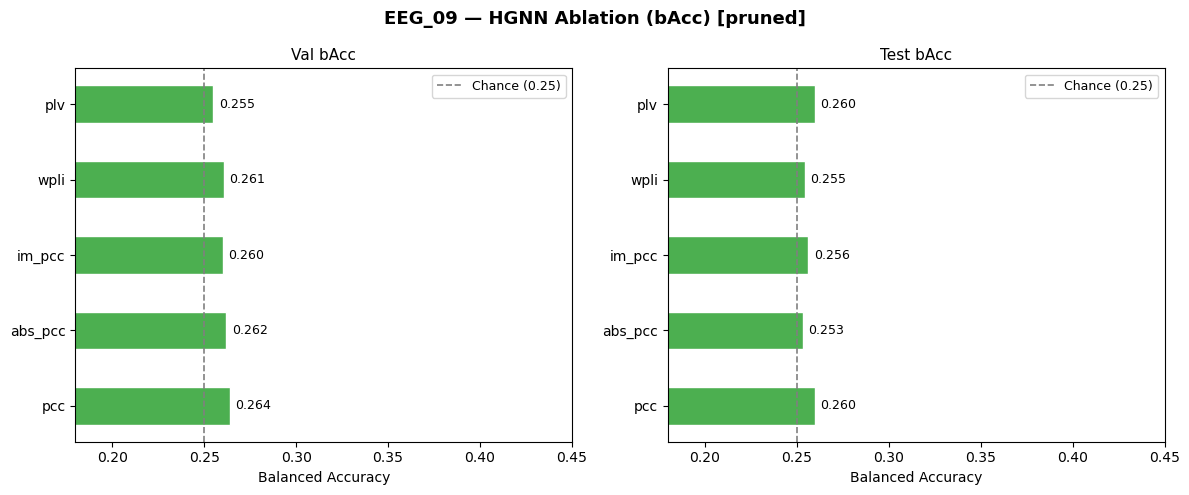

 metric variant  val_bacc  test_bacc
    pcc  pruned  0.263942   0.259934
abs_pcc  pruned  0.261952   0.253360
 im_pcc  pruned  0.260104   0.256389
   wpli  pruned  0.260584   0.254539
    plv  pruned  0.254980   0.259970


In [6]:
if RESULTS:
    var_labels = ['pruned' if v else 'raw' for v in VARIANTS]
    chance = 1 / N_CLASSES

    mat_val  = np.full((len(METRICS), len(var_labels)), np.nan)
    mat_test = np.full((len(METRICS), len(var_labels)), np.nan)
    for i, m in enumerate(METRICS):
        for j, vl in enumerate(var_labels):
            k = f'{m}_{vl}'
            if k in RESULTS:
                mat_val[i, j]  = RESULTS[k]['val']
                mat_test[i, j] = RESULTS[k]['test']

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    variant_str = var_labels[0] if len(var_labels) == 1 else ' × '.join(var_labels)
    fig.suptitle(f'EEG_09 — HGNN Ablation (bAcc) [{variant_str}]', fontsize=13, fontweight='bold')

    if len(var_labels) == 1:
        # Bar chart orizzontale (singola variante — heatmap 5×1 sarebbe sbilanciata)
        for ax, mat, title in zip(axes, [mat_val, mat_test], ['Val bAcc', 'Test bAcc']):
            vals = mat[:, 0]
            colors = ['#4CAF50' if v > chance else '#EF5350' for v in vals]
            bars = ax.barh(METRICS, vals, color=colors, edgecolor='white', height=0.5)
            ax.axvline(chance, color='gray', linestyle='--', linewidth=1.2,
                       label=f'Chance ({chance:.2f})')
            ax.set_xlim(0.18, max(0.45, float(np.nanmax(vals)) + 0.06))
            ax.set_title(title, fontsize=11)
            ax.set_xlabel('Balanced Accuracy')
            ax.legend(fontsize=9)
            for bar, v in zip(bars, vals):
                if not np.isnan(v):
                    ax.text(v + 0.003, bar.get_y() + bar.get_height() / 2,
                            f'{v:.3f}', va='center', fontsize=9)
    else:
        # Heatmap (multi-variante)
        for ax, mat, title in zip(axes, [mat_val, mat_test], ['Val bAcc', 'Test bAcc']):
            vmax = max(chance + 0.15, float(np.nanmax(mat[~np.isnan(mat)])) + 0.02)
            im = ax.imshow(mat, vmin=chance - 0.05, vmax=vmax, cmap='RdYlGn', aspect='auto')
            plt.colorbar(im, ax=ax)
            ax.set_xticks(range(len(var_labels))); ax.set_xticklabels(var_labels, fontsize=10)
            ax.set_yticks(range(len(METRICS)));    ax.set_yticklabels(METRICS, fontsize=10)
            ax.set_title(title, fontsize=11)
            for i in range(len(METRICS)):
                for j in range(len(var_labels)):
                    if not np.isnan(mat[i, j]):
                        ax.text(j, i, f'{mat[i,j]:.3f}', ha='center', va='center', fontsize=9,
                                color='black' if mat[i, j] > chance else 'darkred')

    plt.tight_layout()
    plt.savefig(FIG_DIR / 'eeg09_hgnn_ablation.png', dpi=150, bbox_inches='tight')
    plt.show()

    df = pd.DataFrame([
        {'metric': m, 'variant': vl,
         'val_bacc':  RESULTS.get(f'{m}_{vl}', {}).get('val',  np.nan),
         'test_bacc': RESULTS.get(f'{m}_{vl}', {}).get('test', np.nan)}
        for m in METRICS for vl in var_labels
    ])
    df.to_csv(FIG_DIR / 'eeg09_hgnn_results.csv', index=False)
    print(df.to_string(index=False))